## Chapter 6

##### Question # 8

Train and fine-tune a Decision Tree for the moons dataset by following these
steps:<br>
a. Use make_moons(n_samples=10000, noise=0.4) to generate a moons dataset.<br>
b. Use train_test_split() to split the dataset into a training set and a test set.<br>
c. Use grid search with cross-validation (with the help of the GridSearchCV
class) to find good hyperparameter values for a DecisionTreeClassifier.
Hint: try various values for max_leaf_nodes.<br>
d. Train it on the full training set using these hyperparameters, and measure
your model’s performance on the test set. You should get roughly 85% to 87%
accuracy.

In [4]:
from sklearn.datasets import make_moons
moons = make_moons(n_samples = 1000, noise = 0.4)
X = moons[0]
y = moons[1]

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

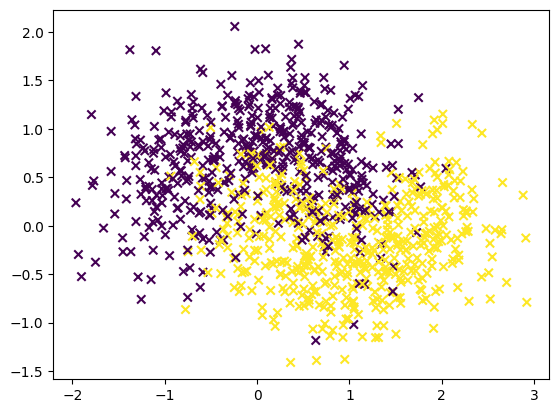

In [10]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', marker='x')

In [11]:
import numpy as np
np.unique_counts(y)

UniqueCountsResult(values=array([0, 1]), counts=array([500, 500]))

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')
grid_moon = GridSearchCV(DecisionTreeClassifier(), param_grid={'max_leaf_nodes' : [1,3,5,7,9,10,15], 'max_depth' : [1,2,3,4,5], 'min_samples_split':[1,2,3,4,5]}, cv = 3, scoring = 'accuracy')
grid_moon.fit(X_train, y_train)
grid_moon.best_score_

np.float64(0.8300151126880873)

In [16]:
moon_model = grid_moon.best_estimator_
moon_pred = moon_model.predict(X_test)
from sklearn.metrics import accuracy_score
accuracy_score(y_test, moon_pred)

0.88